In [51]:
import sys
sys.path.append("..")

import itertools
import pandas as pd
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from src.pair_selection import find_correlated_pairs, find_cointegrated_pairs
from src.spread import compute_spread

## Load the processed price dataset

In [52]:
adj_close_df = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)

## Correlation analysis

Before testing for cointegration, we look at simple correlation between stock prices as a quick first filter. We also compute daily returns, which are often used alongside price correlation to check that stocks move together in the short term.

In [53]:
rns = adj_close_df.pct_change().dropna()
print(rns)

                 AAL      AAPL      ADBE  ...       USB       WFC       WMT
Date                                      ...                              
2017-01-04  0.008639 -0.001120  0.006378  ...  0.007385  0.000893  0.005825
2017-01-05 -0.017345  0.005086  0.016996  ... -0.016783 -0.015522  0.002172
2017-01-06  0.006973  0.011148  0.022566  ...  0.006475 -0.002537 -0.013727
2017-01-09  0.018827  0.009160  0.002493  ... -0.004483 -0.014535  0.006593
2017-01-10  0.029736  0.001009 -0.002855  ...  0.002937  0.007006 -0.006986
...              ...       ...       ...  ...       ...       ...       ...
2024-12-24  0.005797  0.011478  0.002686  ...  0.010555  0.014885  0.025789
2024-12-26  0.000000  0.003176  0.004956  ...  0.003686  0.002375  0.001187
2024-12-27  0.000000 -0.013242 -0.008175  ... -0.010610 -0.009058 -0.012178
2024-12-30  0.015562 -0.013264 -0.001523  ... -0.004949 -0.009844 -0.011892
2024-12-31 -0.010783 -0.007058 -0.002512  ...  0.001675 -0.002414 -0.002429

[2011 rows 

In [54]:
corr_matrix =  adj_close_df.corr()
print(corr_matrix)

            AAL      AAPL      ADBE  ...       USB       WFC       WMT
AAL    1.000000 -0.808314 -0.790154  ...  0.129013  0.150725 -0.753236
AAPL  -0.808314  1.000000  0.832420  ...  0.141815  0.318671  0.920917
ADBE  -0.790154  0.832420  1.000000  ...  0.202308  0.049073  0.752258
ALGT   0.356898 -0.362640 -0.044564  ...  0.473634 -0.228930 -0.433185
ALK    0.818096 -0.625014 -0.619782  ...  0.401599  0.209953 -0.596350
BAC   -0.501532  0.769669  0.707104  ...  0.681094  0.581932  0.741331
BBY   -0.656156  0.692425  0.851628  ...  0.360442 -0.001817  0.665979
BK    -0.165642  0.598318  0.391667  ...  0.545513  0.859695  0.701243
C      0.252436  0.058710  0.130693  ...  0.773257  0.641831  0.205350
COF   -0.418780  0.765246  0.707348  ...  0.670350  0.647021  0.741300
COST  -0.739489  0.948687  0.735998  ...  0.177985  0.490797  0.959788
CRM   -0.733341  0.826554  0.914252  ...  0.248893  0.227844  0.847836
CSCO  -0.678217  0.781205  0.797894  ...  0.337424  0.314483  0.765261
DAL   

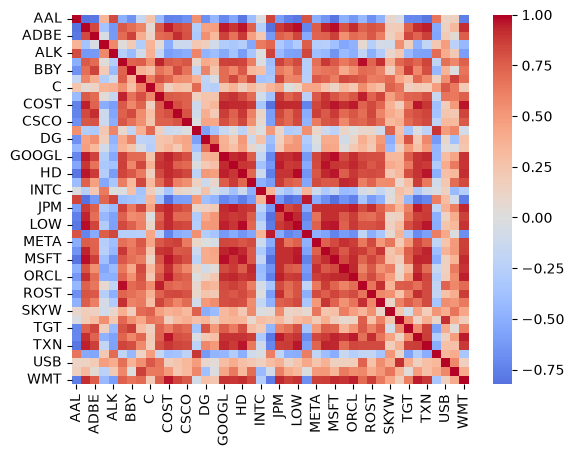

In [62]:
plt.figure()
sns.heatmap(corr_matrix, cmap = "coolwarm", center = 0)
plt.savefig("../figures/correlation_matrix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
correlated_pairs = find_correlated_pairs(adj_close_df, 0.7)
print(correlated_pairs)

[('AAL', 'ALK', np.float64(0.8180962428875052)), ('AAL', 'JBLU', np.float64(0.8491938339855639)), ('AAL', 'LUV', np.float64(0.788191602396652)), ('AAPL', 'ADBE', np.float64(0.8324202804790892)), ('AAPL', 'BAC', np.float64(0.7696691763868672)), ('AAPL', 'COF', np.float64(0.765246316655252)), ('AAPL', 'COST', np.float64(0.9486871938055026)), ('AAPL', 'CRM', np.float64(0.826553832846624)), ('AAPL', 'CSCO', np.float64(0.7812047312896329)), ('AAPL', 'GOOGL', np.float64(0.9560455796577918)), ('AAPL', 'GS', np.float64(0.8920457647987524)), ('AAPL', 'HD', np.float64(0.9584851035333184)), ('AAPL', 'IBM', np.float64(0.7439900790184472)), ('AAPL', 'JPM', np.float64(0.8783542110130622)), ('AAPL', 'KR', np.float64(0.9383742922235928)), ('AAPL', 'LOW', np.float64(0.9749646238467532)), ('AAPL', 'META', np.float64(0.7624570939519659)), ('AAPL', 'MS', np.float64(0.9396499677087324)), ('AAPL', 'MSFT', np.float64(0.9757155165640905)), ('AAPL', 'NVDA', np.float64(0.787909721855244)), ('AAPL', 'ORCL', np.f

## Cointegration analysis

Correlation alone isn't sufficient evidence for pairs trading, since two stocks can be correlated while still drifting apart permanently over time. To find pairs suitable for pairs trading, we test for cointegration: whether a linear combination of the two price series (the spread) is stationary, which means it reverts to a constant mean rather than drifting indefinitely.

We use the Engle-Granger test (`coint()` from statsmodels), which regresses one price on the other and tests the residual for stationarity using the Augmented Dickey-Fuller test. A low p-value (< 0.05) indicates strong evidence that the pair is cointegrated. We only test pairs that passed the correlation filter, to reduce computation time.

In [57]:
cointegrated_pairs = find_cointegrated_pairs(adj_close_df, correlated_pairs, 0.05)
print(cointegrated_pairs)

[('AAPL', 'KR', np.float64(0.9383742922235928), np.float64(0.010046706593916661)), ('AAPL', 'LOW', np.float64(0.9749646238467532), np.float64(0.016529029855566073)), ('ADBE', 'BBY', np.float64(0.8516281511761593), np.float64(0.031205580411501805)), ('BAC', 'COF', np.float64(0.9417616750803479), np.float64(0.014256793158484627)), ('BAC', 'GOOGL', np.float64(0.8551191794067107), np.float64(0.045515339737503824)), ('BAC', 'PNC', np.float64(0.9783670549514576), np.float64(0.0027396269600102824)), ('BBY', 'TGT', np.float64(0.8690423433609983), np.float64(0.01961239924273237)), ('C', 'SKYW', np.float64(0.7461921655949459), np.float64(0.046705611505093905)), ('COF', 'PNC', np.float64(0.9435954438994331), np.float64(0.03373273118754412)), ('GOOGL', 'HD', np.float64(0.9486025715330391), np.float64(0.02048852266716692)), ('GOOGL', 'MS', np.float64(0.9419589168599823), np.float64(0.046870079257740095)), ('HD', 'KR', np.float64(0.8941817589109641), np.float64(0.012528809132131617)), ('HD', 'MS', n

In [58]:
cointegrated_pairs.sort(key = lambda x: x[3])
print(cointegrated_pairs[:10])

[('JBLU', 'LUV', np.float64(0.9504446769104575), np.float64(7.109656764761808e-05)), ('IBM', 'NVDA', np.float64(0.9337247835493235), np.float64(0.0005359489098957562)), ('BAC', 'PNC', np.float64(0.9783670549514576), np.float64(0.0027396269600102824)), ('LOW', 'TXN', np.float64(0.9639634259286295), np.float64(0.003730076780253883)), ('KR', 'MS', np.float64(0.911440969972917), np.float64(0.00901795794039746)), ('AAPL', 'KR', np.float64(0.9383742922235928), np.float64(0.010046706593916661)), ('HD', 'MSFT', np.float64(0.9610182248699785), np.float64(0.010522624128841066)), ('KR', 'LOW', np.float64(0.9297815619524303), np.float64(0.011338316873933814)), ('HD', 'TXN', np.float64(0.9618333631161443), np.float64(0.011829046251158904)), ('HD', 'KR', np.float64(0.8941817589109641), np.float64(0.012528809132131617))]


## Visualizing Top Candidate Pairs

For each of the top 10 cointegrated pairs, we plot the price series of both stocks alongside their spread. The spread should fluctuate around a stable mean of 0 if the pair is genuinely cointegrated — this is what we visually check to confirm the statistical test results before moving forward with strategy design.

<Figure size 640x480 with 0 Axes>

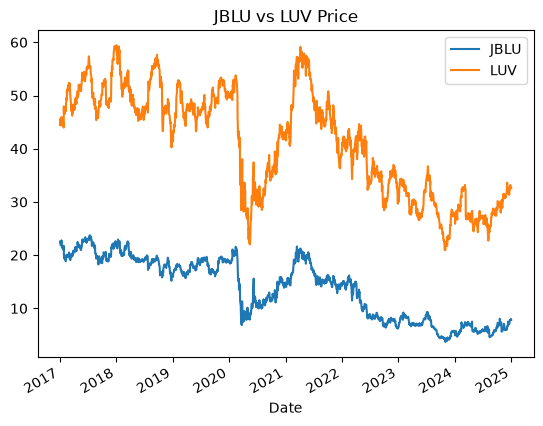

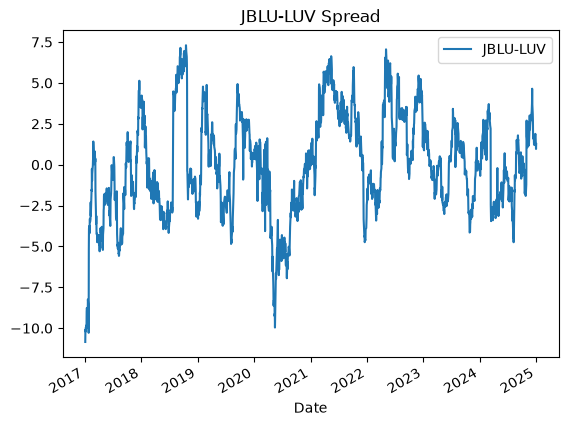

<Figure size 640x480 with 0 Axes>

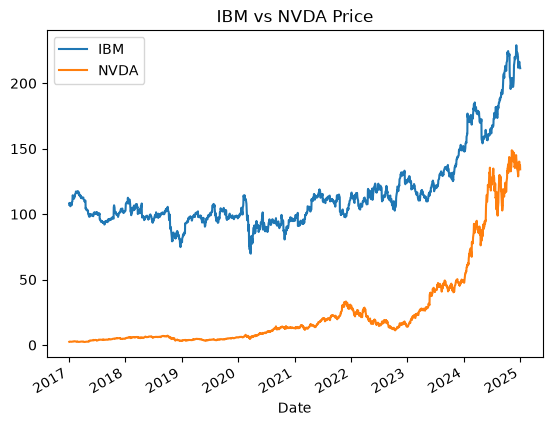

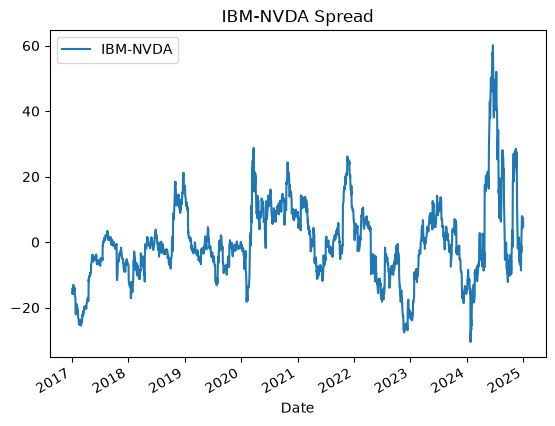

<Figure size 640x480 with 0 Axes>

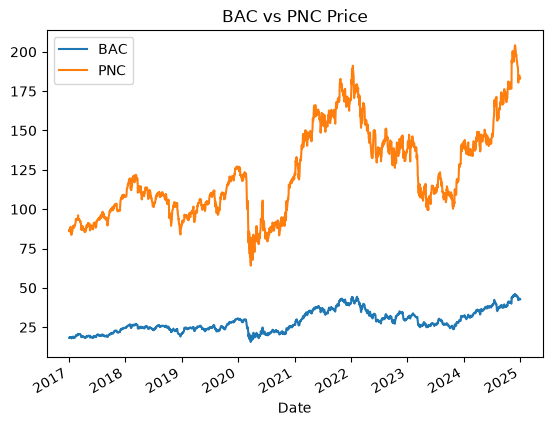

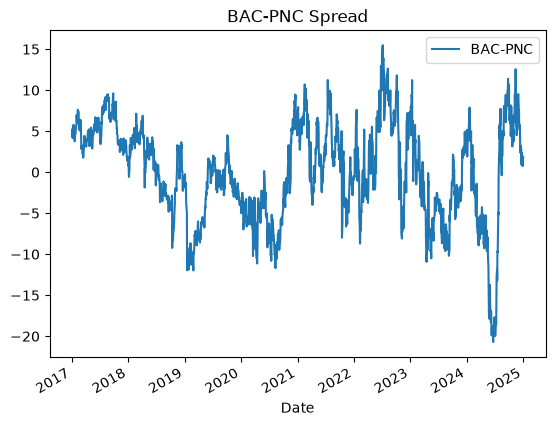

<Figure size 640x480 with 0 Axes>

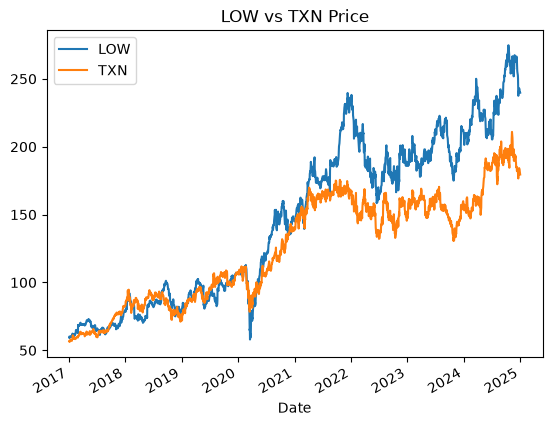

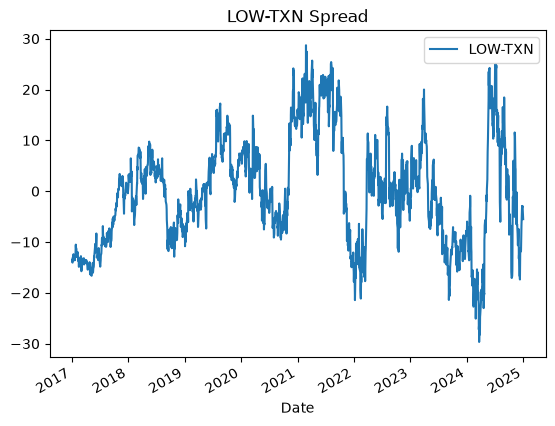

<Figure size 640x480 with 0 Axes>

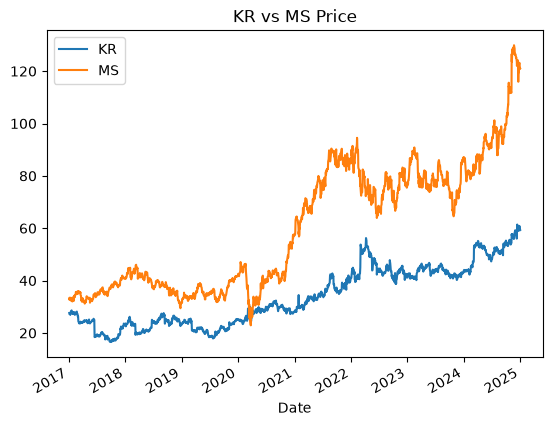

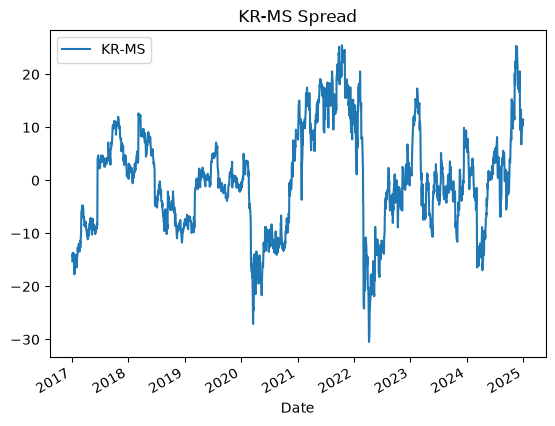

<Figure size 640x480 with 0 Axes>

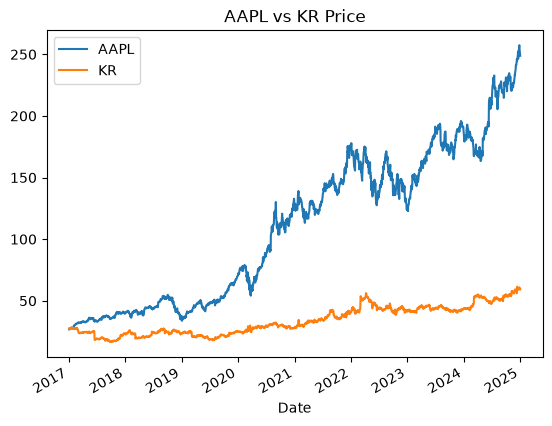

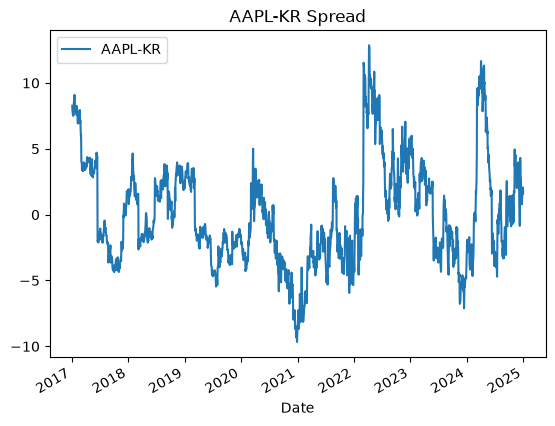

<Figure size 640x480 with 0 Axes>

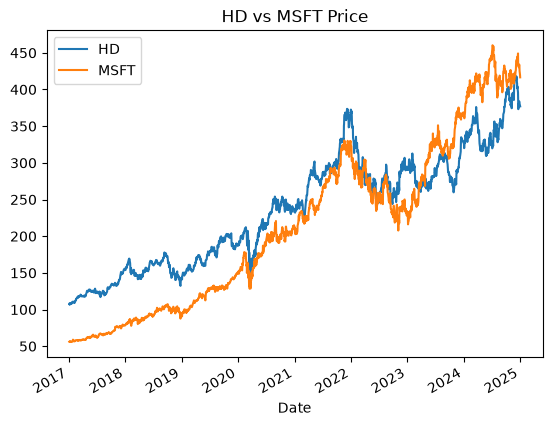

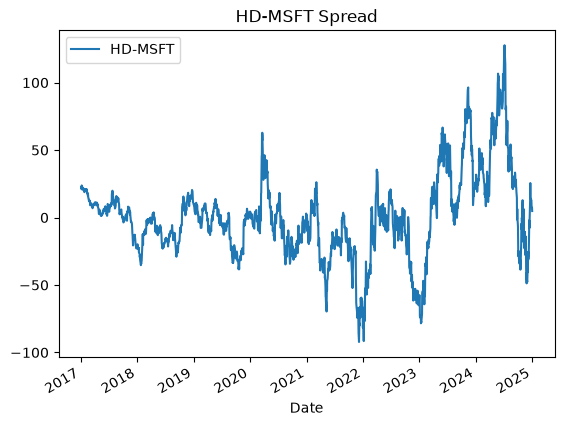

<Figure size 640x480 with 0 Axes>

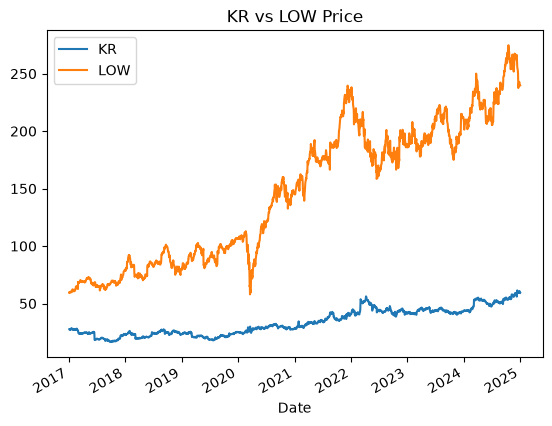

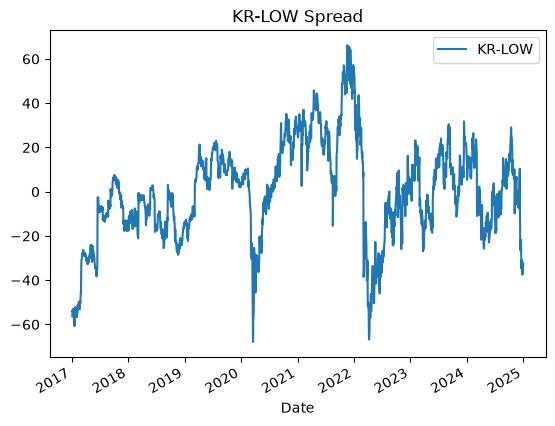

<Figure size 640x480 with 0 Axes>

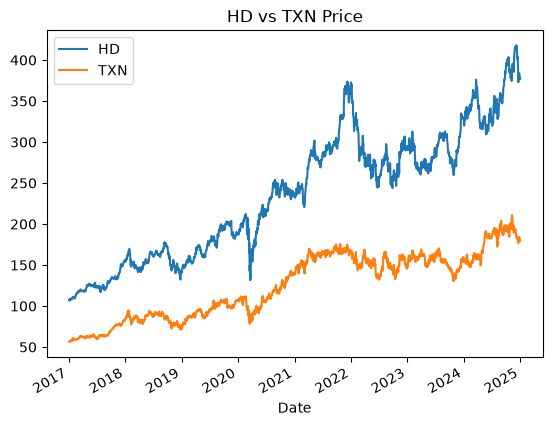

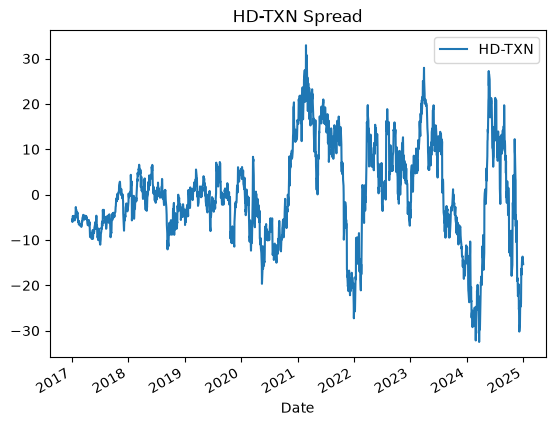

<Figure size 640x480 with 0 Axes>

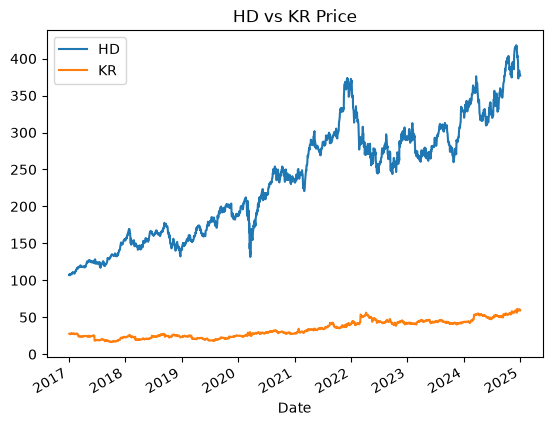

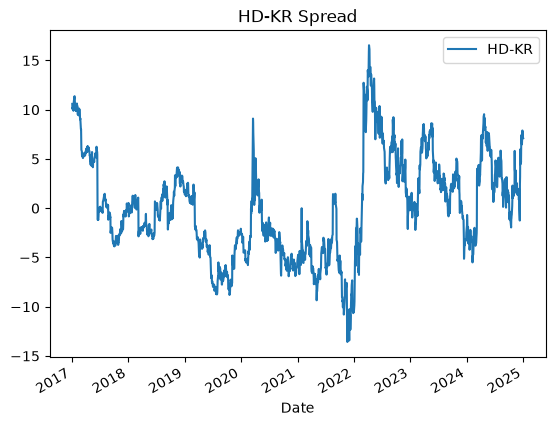

In [64]:
for i in range(10):
    cointegrated_pair = cointegrated_pairs[i]
    t1, t2 = cointegrated_pair[0], cointegrated_pair[1]

    plt.figure()
    adj_close_df[[t1, t2]].plot(title=f"{t1} vs {t2} Price")
    if i == 0:
        plt.savefig("../figures/JBLU_vs_LUV_price.png", dpi = 150, bbox_inches="tight")
    plt.show()

    spread = compute_spread(adj_close_df, cointegrated_pair)[2]
    plt.figure()
    spread.plot(title = f"{t1}-{t2} Spread", label = f"{t1}-{t2}")
    plt.legend()
    if i == 0:
        plt.savefig("../figures/JBLU_LUV_spread.png", dpi = 150, bbox_inches="tight")
    plt.show()


## Top Cointegrated Pairs Analysis

1. The JBLU-LUV spread oscillates around 0 throughout the period with no persistent long-term drift, consistent with its very low p-value (~0.00007) from the cointegration test.
2. The IBM-NVDA spread shows several large swings but still repeatedly comes back toward its central level rather than trending away indefinitely.
3. The BAC-PNC spread appears to drift within a roughly bounded band, with sharp deviations often followed by reversal toward the spread’s mean.
4. The LOW-TXN spread has a generally flat long-term mean and many spikes that are corrected, suggesting the series remains mean-reverting.
5. The KR-MS spread moves around a stable middle range with big excursions that are mostly followed by reversion rather than permanent drift.
6. The AAPL-KR spread stays near a recurring center for most of the interval, with deviations that reverse rather than simply wandering off.
7. The HD-MSFT spread is volatile but still oscillates around a consistent baseline instead of drifting steadily upward or downward.
8. The KR-LOW spread exhibits wide swings but continues to return toward its long-run mean, indicating strong reversion behavior.
9. The HD-TXN spread has episodic large moves, yet each extreme tends to unwind back toward the central band rather than persistently trend.
10. The HD-KR spread remains centered around an apparent equilibrium level, with deviations that generally reverse after reaching extremes.
